### Start


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"briemoller","key":"dd4c33ff0fb4e883fa84aa5f78c3b61e"}'}

In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d ankit1743/skyview-an-aerial-landscape-dataset

Dataset URL: https://www.kaggle.com/datasets/ankit1743/skyview-an-aerial-landscape-dataset
License(s): CC0-1.0


In [5]:
import zipfile

with zipfile.ZipFile("skyview-an-aerial-landscape-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("skyview_dataset")


### Data Processing

In [7]:
import os, shutil
import random
from pathlib import Path

original_dir = Path("/content/skyview_dataset/Aerial_Landscapes")
train_dir = Path("/content/gdrive/MyDrive/9517 project/data/train")
test_dir = Path("/content/gdrive/MyDrive/9517 project/data/test")

for d in [train_dir, test_dir]:
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True)

random.seed(42)

for category in sorted(os.listdir(original_dir)):
    cat_path = original_dir / category
    if not cat_path.is_dir(): continue

    imgs = list(cat_path.glob("*"))
    random.shuffle(imgs)
    split = int(0.8 * len(imgs))
    train_imgs, test_imgs = imgs[:split], imgs[split:]

    (train_dir / category).mkdir(parents=True)
    (test_dir / category).mkdir(parents=True)

    for img in train_imgs:
        shutil.copy(img, train_dir / category / img.name)
    for img in test_imgs:
        shutil.copy(img, test_dir / category / img.name)

### EfficientNet

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report
from torchvision.models import efficientnet_b0
from tqdm import tqdm
from torchvision.datasets import ImageFolder

train_path = "/content/gdrive/MyDrive/9517 project/data/train" #path of traing data
test_path = "/content/gdrive/MyDrive/9517 project/data/test" #path of testing data

class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        path = self.imgs[index][0]  #
        return img, label, path

#traing data agumentation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])
train_data = datasets.ImageFolder(train_path, transform=transform_train)
test_data = ImageFolderWithPaths(test_path, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

# The define of model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = efficientnet_b0(pretrained=True)  # The model:EfficientNet-B0
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(train_data.classes))
model = model.to(device)
# The configuration of training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Strat training
for epoch in range(12): #change the number of epoch you wanna train
    print(f"start  {epoch+1}  epoch")
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", unit="batch")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")
torch.save(model.state_dict(), "/content/gdrive/MyDrive/9517 project/Efficientnet_epoch12.pth")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


start  1  epoch


Epoch 1: 100%|██████████| 300/300 [01:47<00:00,  2.79batch/s, loss=0.283]


Epoch 1: Loss = 265.6576
start  2  epoch


Epoch 2: 100%|██████████| 300/300 [01:44<00:00,  2.88batch/s, loss=0.212]


...

Epoch 10: Loss = 6.9304
start  11  epoch


Epoch 11: 100%|██████████| 300/300 [01:44<00:00,  2.87batch/s, loss=0.00492]


Epoch 11: Loss = 7.6005
start  12  epoch


Epoch 12: 100%|██████████| 300/300 [01:51<00:00,  2.69batch/s, loss=0.0147]

Epoch 12: Loss = 6.9884


In [9]:
# Data Processing + Model Loading
import os
import shutil
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import transforms, datasets
from torchvision.models import efficientnet_b0
from torch.utils.data import DataLoader
from PIL import Image

train_path = "/content/gdrive/MyDrive/9517 project/data/train"
test_path = "/content/gdrive/MyDrive/9517 project/data/test"
model_path = "/content/gdrive/MyDrive/9517 project/Efficientnet_epoch12.pth"

shutil.rmtree("/content/gdrive/MyDrive/9517 project/Efficientnet/gradcam_heatmaps", ignore_errors=True)
shutil.rmtree("/content/gdrive/MyDrive/9517 project/Efficientnet/misclassified_images", ignore_errors=True)
shutil.rmtree("/content/gdrive/MyDrive/9517 project/Efficientnet/similar_images", ignore_errors=True)

os.makedirs("/content/gdrive/MyDrive/9517 project/Efficientnet/gradcam_heatmaps", exist_ok=True)
os.makedirs("/content/gdrive/MyDrive/9517 project/Efficientnet/misclassified_images", exist_ok=True)
os.makedirs("/content/gdrive/MyDrive/9517 project/Efficientnet/similar_images", exist_ok=True)

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        original = super().__getitem__(index)
        path = self.imgs[index][0]
        return original + (path,)

train_data = datasets.ImageFolder(train_path)
test_data = ImageFolderWithPaths(test_path, transform=transform_test)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(train_data.classes))
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

feature_extractor = nn.Sequential(*list(model.children())[:-1]).to(device).eval()

In [10]:
# Prediction & Feature Extraction
all_preds, all_labels, all_paths, all_features = [], [], [], []
misclassified_info = []

with torch.no_grad():
    for imgs, labels, paths in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        feats = feature_extractor(imgs).squeeze(-1).squeeze(-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_paths.extend(paths)
        all_features.append(feats.cpu().numpy())

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified_info.append({
                    'filename': paths[i],
                    'true_label': test_data.classes[labels[i]],
                    'predicted_label': test_data.classes[preds[i]],
                    'feature': feats[i].cpu().numpy()
                })

all_features = np.concatenate(all_features, axis=0)
df_all = pd.DataFrame({
    'path': all_paths,
    'label': [test_data.classes[y] for y in all_labels],
    'pred': [test_data.classes[y] for y in all_preds],
    'feature': list(all_features)
})


Classification Report:
              precision    recall  f1-score   support

 Agriculture       0.98      0.97      0.98       160
     Airport       1.00      0.97      0.99       160
       Beach       0.99      1.00      1.00       160
        City       0.98      0.99      0.98       160
      Desert       0.99      0.96      0.97       160
      Forest       0.98      0.99      0.99       160
   Grassland       1.00      0.96      0.98       160
     Highway       0.98      0.99      0.98       160
        Lake       0.98      0.99      0.99       160
    Mountain       0.95      0.98      0.97       160
     Parking       1.00      0.98      0.99       160
        Port       0.98      1.00      0.99       160
     Railway       0.99      0.97      0.98       160
 Residential       0.99      1.00      1.00       160
       River       0.96      0.98      0.97       160

    accuracy                           0.98      2400
   macro avg       0.98      0.98      0.98      2400
wei

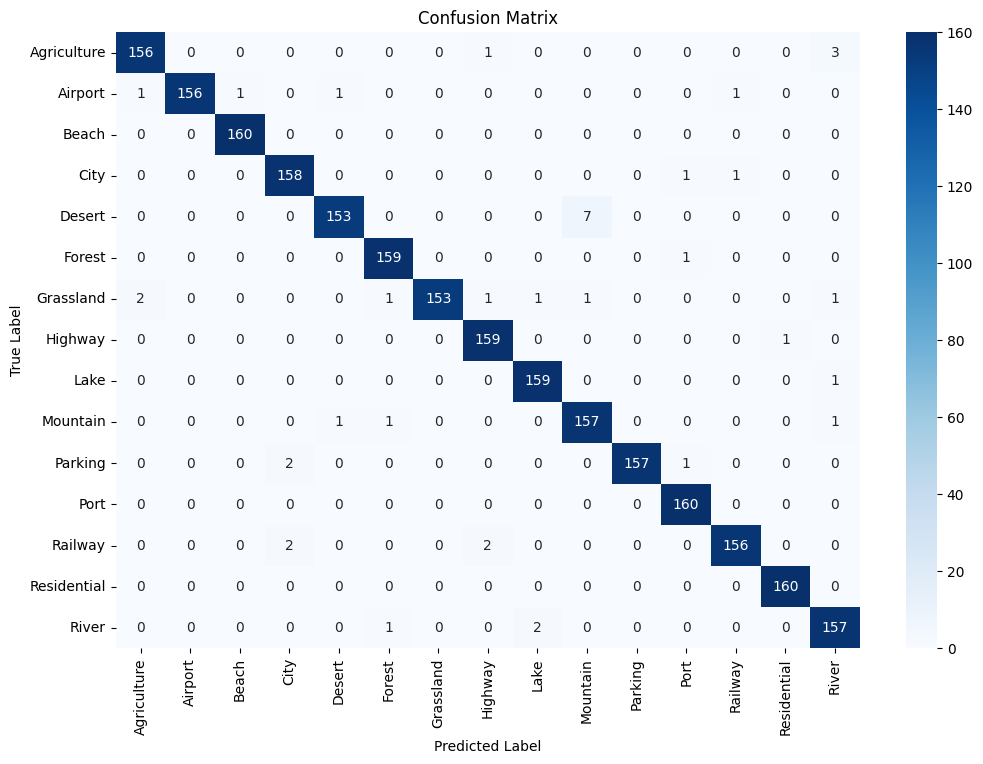

In [11]:
import cv2
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        loss = output[0, class_idx]
        loss.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def overlay_heatmap(img_path, cam):
    raw = cv2.imread(img_path)
    raw = cv2.resize(raw, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(raw, 0.5, heatmap, 0.5, 0)
    return overlay

# Grad-CAM
target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

similarity_records = []
for item in misclassified_info:
    f1 = item['feature'].reshape(1, -1)
    pred_class = item['predicted_label']

    candidates = df_all[df_all['label'] == pred_class]
    candidate_feats = np.stack(candidates['feature'].values)
    similarities = cosine_similarity(f1, candidate_feats).flatten()
    max_idx = np.argmax(similarities)

    similar_path = candidates.iloc[max_idx]['path']
    similarity_records.append({
        'wrong_image': item['filename'],
        'true_label': item['true_label'],
        'predicted_label': item['predicted_label'],
        'similar_image': similar_path,
        'similarity': similarities[max_idx]
    })

    shutil.copy(item['filename'], os.path.join("/content/gdrive/MyDrive/9517 project/Efficientnet/misclassified_images", os.path.basename(item['filename'])))
    shutil.copy(similar_path, os.path.join("/content/gdrive/MyDrive/9517 project/Efficientnet/similar_images", os.path.basename(similar_path)))

    input_image = Image.open(item['filename']).convert('RGB')
    input_tensor = transform_test(input_image).unsqueeze(0).to(device)
    cam = gradcam.generate(input_tensor)
    heatmap_image = overlay_heatmap(item['filename'], cam)
    heatmap_path = os.path.join("/content/gdrive/MyDrive/9517 project/Efficientnet/gradcam_heatmaps", os.path.basename(item['filename']))
    cv2.imwrite(heatmap_path, heatmap_image)

# Save Similar Image Matching Results
df_sim = pd.DataFrame(similarity_records)
df_sim.to_csv("/content/gdrive/MyDrive/9517 project/Efficientnet/misclassified_similarity.csv", index=False)

# Output Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

# Output Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=test_data.classes, yticklabels=test_data.classes, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### ResNet

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report
from tqdm import tqdm
from torchvision.datasets import ImageFolder

train_path = "/content/gdrive/MyDrive/9517 project/data/train" #change it to your own training data path
test_path = "/content/gdrive/MyDrive/9517 project/data/test" #change it to your own testing data path

class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        path = self.imgs[index][0]  # get the path of picture
        return img, label, path


# Training Data Augmentatio
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# process thet testing data
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder(train_path, transform=transform_train)
test_data = ImageFolderWithPaths(test_path, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

# The define of model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#The name of the model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))
model = model.to(device)

# the configuration of traing
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# start training
for epoch in range(12):  #change the number of model you wanna train
    print(f"start  {epoch+1} epoch")
    model.train()
    total_loss = 0


    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", unit="batch")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")
torch.save(model.state_dict(), "/content/gdrive/MyDrive/9517 project/resnet18_epoch12.pth")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


start  1 epoch


Epoch 1: 100%|██████████| 300/300 [01:28<00:00,  3.39batch/s, loss=0.271]


Epoch 1: Loss = 133.6897
start  2 epoch


Epoch 2: 100%|██████████| 300/300 [01:27<00:00,  3.44batch/s, loss=0.227]


...

Epoch 10: Loss = 10.6398
start  11 epoch


Epoch 11: 100%|██████████| 300/300 [01:26<00:00,  3.46batch/s, loss=0.00567]


Epoch 11: Loss = 10.5538
start  12 epoch


Epoch 12: 100%|██████████| 300/300 [01:25<00:00,  3.49batch/s, loss=0.00634]

Epoch 12: Loss = 7.7600


In [13]:

train_path = "/content/gdrive/MyDrive/9517 project/data/train"
test_path = "/content/gdrive/MyDrive/9517 project/data/test"
model_path = "/content/gdrive/MyDrive/9517 project/resnet18_epoch12.pth"

shutil.rmtree("/content/gdrive/MyDrive/9517 project/Resnet/gradcam_heatmaps", ignore_errors=True)
shutil.rmtree("/content/gdrive/MyDrive/9517 project/Resnet/misclassified_images", ignore_errors=True)
shutil.rmtree("/content/gdrive/MyDrive/9517 project/Resnet/similar_images", ignore_errors=True)
os.makedirs("/content/gdrive/MyDrive/9517 project/Resnet/gradcam_heatmaps", exist_ok=True)
os.makedirs("/content/gdrive/MyDrive/9517 project/Resnet/misclassified_images", exist_ok=True)
os.makedirs("/content/gdrive/MyDrive/9517 project/Resnet/similar_images", exist_ok=True)

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        original = super().__getitem__(index)
        path = self.imgs[index][0]
        return original + (path,)

train_data = datasets.ImageFolder(train_path)
test_data = ImageFolderWithPaths(test_path, transform=transform_test)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

feature_extractor = nn.Sequential(*list(model.children())[:-1]).to(device).eval()

In [14]:
all_preds, all_labels, all_paths, all_features = [], [], [], []
misclassified_info = []

with torch.no_grad():
    for imgs, labels, paths in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        feats = feature_extractor(imgs).squeeze(-1).squeeze(-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_paths.extend(paths)
        all_features.append(feats.cpu().numpy())

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified_info.append({
                    'filename': paths[i],
                    'true_label': test_data.classes[labels[i]],
                    'predicted_label': test_data.classes[preds[i]],
                    'feature': feats[i].cpu().numpy()
                })

all_features = np.concatenate(all_features, axis=0)
df_all = pd.DataFrame({
    'path': all_paths,
    'label': [test_data.classes[y] for y in all_labels],
    'pred': [test_data.classes[y] for y in all_preds],
    'feature': list(all_features)
})

Classification Report:
              precision    recall  f1-score   support

 Agriculture       0.99      0.94      0.96       160
     Airport       0.94      0.97      0.96       160
       Beach       0.98      0.99      0.98       160
        City       0.99      0.93      0.96       160
      Desert       0.95      0.99      0.97       160
      Forest       0.96      0.98      0.97       160
   Grassland       0.99      0.97      0.98       160
     Highway       0.98      0.99      0.98       160
        Lake       0.99      0.98      0.98       160
    Mountain       0.99      0.96      0.98       160
     Parking       0.98      0.98      0.98       160
        Port       0.99      0.98      0.98       160
     Railway       0.94      0.96      0.95       160
 Residential       0.98      0.99      0.98       160
       River       0.97      0.98      0.98       160

    accuracy                           0.97      2400
   macro avg       0.97      0.97      0.97      2400
wei

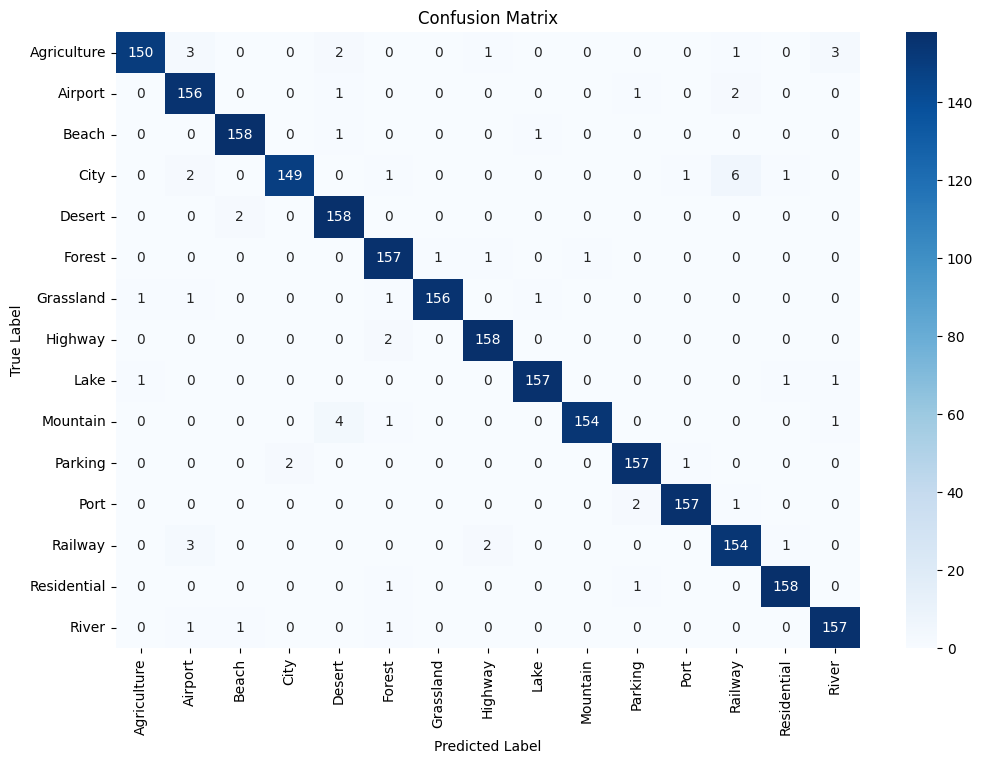

In [15]:
import cv2
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        loss = output[0, class_idx]
        loss.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def overlay_heatmap(img_path, cam):
    raw = cv2.imread(img_path)
    raw = cv2.resize(raw, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(raw, 0.5, heatmap, 0.5, 0)
    return overlay

# Grad-CAM target layer for ResNet: layer4
target_layer = model.layer4
gradcam = GradCAM(model, target_layer)

similarity_records = []
for item in misclassified_info:
    f1 = item['feature'].reshape(1, -1)
    pred_class = item['predicted_label']

    candidates = df_all[df_all['label'] == pred_class]
    candidate_feats = np.stack(candidates['feature'].values)
    similarities = cosine_similarity(f1, candidate_feats).flatten()
    max_idx = np.argmax(similarities)

    similar_path = candidates.iloc[max_idx]['path']
    similarity_records.append({
        'wrong_image': item['filename'],
        'true_label': item['true_label'],
        'predicted_label': item['predicted_label'],
        'similar_image': similar_path,
        'similarity': similarities[max_idx]
    })

    shutil.copy(item['filename'], os.path.join("/content/gdrive/MyDrive/9517 project/Resnet/misclassified_images", os.path.basename(item['filename'])))
    shutil.copy(similar_path, os.path.join("/content/gdrive/MyDrive/9517 project/Resnet/similar_images", os.path.basename(similar_path)))

    input_image = Image.open(item['filename']).convert('RGB')
    input_tensor = transform_test(input_image).unsqueeze(0).to(device)
    cam = gradcam.generate(input_tensor)
    heatmap_image = overlay_heatmap(item['filename'], cam)
    heatmap_path = os.path.join("/content/gdrive/MyDrive/9517 project/Resnet/gradcam_heatmaps", os.path.basename(item['filename']))
    cv2.imwrite(heatmap_path, heatmap_image)

df_sim = pd.DataFrame(similarity_records)
df_sim.to_csv("/content/gdrive/MyDrive/9517 project/Resnet/misclassified_similarity.csv", index=False)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=test_data.classes, yticklabels=test_data.classes, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### SENet


In [16]:
!pip install pretrainedmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.7 MB/s eta 0:00:00
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report
import pretrainedmodels
from tqdm import tqdm
from torchvision.datasets import ImageFolder


train_path = "/content/gdrive/MyDrive/9517 project/data/train" #the path of training data
test_path = "/content/gdrive/MyDrive/9517 project/data/test" #the path of testing data
class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        path = self.imgs[index][0]
        return img, label, path


# training data augmentation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


train_data = datasets.ImageFolder(train_path, transform=transform_train)
test_data = ImageFolderWithPaths(test_path, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

# The define of model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = pretrainedmodels.__dict__['se_resnet50'](pretrained='imagenet')

# change the output to 15 layer (because our data have 15 class)
num_features = model.last_linear.in_features
model.last_linear = nn.Linear(num_features, 15)

model = model.to(device)
# the configuration of training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


# start training
for epoch in range(12): #change the number of epoch you wanna train
    print(f"start {epoch+1}  epoch")
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", unit="batch")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")
torch.save(model.state_dict(), "/content/gdrive/MyDrive/9517 project/SENet_epoch12.pth")

Downloading: "http://data.lip6.fr/cadene/pretrainedmodels/se_resnet50-ce0d4300.pth" to /root/.cache/torch/hub/checkpoints/se_resnet50-ce0d4300.pth
100%|██████████| 107M/107M [00:07<00:00, 15.9MB/s]


start 1  epoch


Epoch 1: 100%|██████████| 300/300 [02:52<00:00,  1.74batch/s, loss=0.0822]


Epoch 1: Loss = 122.1322
start 2  epoch


Epoch 2: 100%|██████████| 300/300 [02:35<00:00,  1.93batch/s, loss=0.344]


...

Epoch 10: Loss = 11.0946
start 11  epoch


Epoch 11: 100%|██████████| 300/300 [02:34<00:00,  1.95batch/s, loss=0.00725]


Epoch 11: Loss = 9.0848
start 12  epoch


Epoch 12: 100%|██████████| 300/300 [02:34<00:00,  1.94batch/s, loss=0.113]


Epoch 12: Loss = 8.9771


In [18]:
import os
import shutil
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import pretrainedmodels

train_path = "/content/gdrive/MyDrive/9517 project/data/train"
test_path = "/content/gdrive/MyDrive/9517 project/data/test"
model_path = "/content/gdrive/MyDrive/9517 project/SENet_epoch12.pth"

shutil.rmtree("/content/gdrive/MyDrive/9517 project/SENet/gradcam_heatmaps", ignore_errors=True)
shutil.rmtree("/content/gdrive/MyDrive/9517 project/SENet/misclassified_images", ignore_errors=True)
shutil.rmtree("/content/gdrive/MyDrive/9517 project/SENet/similar_images", ignore_errors=True)

os.makedirs("/content/gdrive/MyDrive/9517 project/SENet/gradcam_heatmaps", exist_ok=True)
os.makedirs("/content/gdrive/MyDrive/9517 project/SENet/misclassified_images", exist_ok=True)
os.makedirs("/content/gdrive/MyDrive/9517 project/SENet/similar_images", exist_ok=True)

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        original = super().__getitem__(index)
        path = self.imgs[index][0]
        return original + (path,)

train_data = datasets.ImageFolder(train_path)
test_data = ImageFolderWithPaths(test_path, transform=transform_test)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = pretrainedmodels.__dict__['se_resnet50'](pretrained='imagenet')
model.last_linear = nn.Linear(model.last_linear.in_features, len(train_data.classes))
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

feature_extractor = nn.Sequential(*list(model.children())[:-2]).to(device).eval()

In [19]:
all_preds, all_labels, all_paths, all_features = [], [], [], []
misclassified_info = []

with torch.no_grad():
    for imgs, labels, paths in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        feats = feature_extractor(imgs).mean(dim=[2, 3])

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_paths.extend(paths)
        all_features.append(feats.cpu().numpy())

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified_info.append({
                    'filename': paths[i],
                    'true_label': test_data.classes[labels[i]],
                    'predicted_label': test_data.classes[preds[i]],
                    'feature': feats[i].cpu().numpy()
                })

all_features = np.concatenate(all_features, axis=0)
df_all = pd.DataFrame({
    'path': all_paths,
    'label': [test_data.classes[y] for y in all_labels],
    'pred': [test_data.classes[y] for y in all_preds],
    'feature': list(all_features)
})


Classification Report:
              precision    recall  f1-score   support

 Agriculture       0.98      0.99      0.98       160
     Airport       0.88      0.97      0.93       160
       Beach       0.98      0.99      0.98       160
        City       0.95      0.98      0.97       160
      Desert       0.99      0.96      0.97       160
      Forest       0.98      0.99      0.98       160
   Grassland       0.99      0.96      0.97       160
     Highway       0.99      0.97      0.98       160
        Lake       0.95      0.99      0.97       160
    Mountain       0.97      0.99      0.98       160
     Parking       1.00      0.97      0.98       160
        Port       0.99      0.99      0.99       160
     Railway       0.96      0.97      0.97       160
 Residential       0.98      0.99      0.98       160
       River       0.99      0.84      0.91       160

    accuracy                           0.97      2400
   macro avg       0.97      0.97      0.97      2400
wei

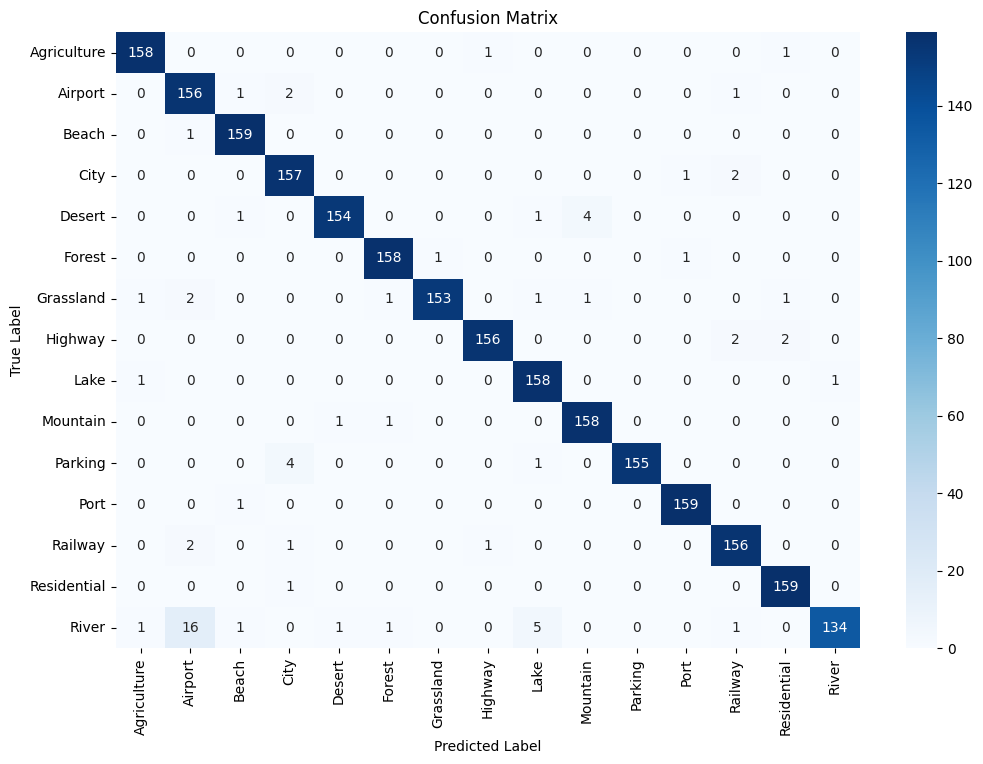

In [20]:
import cv2
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Grad-CAM
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        loss = output[0, class_idx]
        loss.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

def overlay_heatmap(img_path, cam):
    raw = cv2.imread(img_path)
    raw = cv2.resize(raw, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(raw, 0.5, heatmap, 0.5, 0)
    return overlay

# Grad-CAM target layer for SENet: layer4
target_layer = model.layer4
gradcam = GradCAM(model, target_layer)

similarity_records = []
for item in misclassified_info:
    f1 = item['feature'].reshape(1, -1)
    pred_class = item['predicted_label']
    candidates = df_all[df_all['label'] == pred_class]
    candidate_feats = np.stack(candidates['feature'].values)
    similarities = cosine_similarity(f1, candidate_feats).flatten()
    max_idx = np.argmax(similarities)
    similar_path = candidates.iloc[max_idx]['path']

    similarity_records.append({
        'wrong_image': item['filename'],
        'true_label': item['true_label'],
        'predicted_label': item['predicted_label'],
        'similar_image': similar_path,
        'similarity': similarities[max_idx]
    })

    shutil.copy(item['filename'], os.path.join("/content/gdrive/MyDrive/9517 project/SENet/misclassified_images", os.path.basename(item['filename'])))
    shutil.copy(similar_path, os.path.join("/content/gdrive/MyDrive/9517 project/SENet/similar_images", os.path.basename(similar_path)))

    input_image = Image.open(item['filename']).convert('RGB')
    input_tensor = transform_test(input_image).unsqueeze(0).to(device)
    cam = gradcam.generate(input_tensor)
    heatmap_image = overlay_heatmap(item['filename'], cam)
    heatmap_path = os.path.join("/content/gdrive/MyDrive/9517 project/SENet/gradcam_heatmaps", os.path.basename(item['filename']))
    cv2.imwrite(heatmap_path, heatmap_image)

df_sim = pd.DataFrame(similarity_records)
df_sim.to_csv("/content/gdrive/MyDrive/9517 project/SENet/misclassified_similarity.csv", index=False)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_data.classes))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=test_data.classes, yticklabels=test_data.classes, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
